# Summary: AI vs Physics Models & Cross-Year RMSE Comparison

Aggregates results from the three experiment notebooks (2016, 2018, 2022) into
two summary plots.

**Prerequisites:** run the three experiment notebooks first so that `metrics.csv`
is saved in each figure directory.

| Year | Period | Models |
|---|---|---|
| 2016 | 2016-01-01 → 2016-05-12 | FCN3, HRES |
| 2018 | 2018-01-01 → 2018-05-20 | FCN3, HRES |
| 2022 | 2022-01-01 → 2022-01-28 | FCN3, GraphCast, Pangu, HRES |

All comparisons: +12 h lead, valid 12:00 UTC, obs = 12h trailing mean.


In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path


In [2]:
FIG_BASE = Path('/cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures')
FIG_OUT  = FIG_BASE / 'comparison_summary'
FIG_OUT.mkdir(parents=True, exist_ok=True)

METRIC_PATHS = {
    '2016': FIG_BASE / 'fcn3_hres_2016'              / 'metrics.csv',
    '2018': FIG_BASE / 'fcn3_hres_2018'              / 'metrics.csv',
    '2022': FIG_BASE / 'fcn3_gc_pangu_hres_2022_12h' / 'metrics.csv',
}

STATIONS = {
    'SN88690': 'Hekkingen Fyr',
    'SN90490': 'Tromsoe-Langnes',
    'SN90760': 'Fakken',
}

CLR = {
    'FCN3':      '#E74C3C',
    'GraphCast': '#2980B9',
    'Pangu':     '#16A085',
    'HRES':      '#E67E22',
}

AI_MODELS      = ['FCN3', 'GraphCast', 'Pangu']
PHYSICS_MODELS = ['HRES']


## 1  Load Metrics from Experiment Notebooks

In [3]:
dfs = {}
for year, path in METRIC_PATHS.items():
    if not path.exists():
        print(f'WARNING: {path} not found. Run the {year} notebook first.')
        continue
    df = pd.read_csv(path, index_col=0)
    dfs[year] = df
    print(f'{year}: {df.shape[0]} rows, models={[c.split()[0] for c in df.columns if "RMSE" in c]}')

if not dfs:
    raise RuntimeError('No metrics CSVs found. Run all three experiment notebooks first.')


2016: 4 rows, models=['FCN3', 'HRES', 'ΔRMSE']
2018: 4 rows, models=['FCN3', 'HRES', 'ΔRMSE']
2022: 4 rows, models=['FCN3', 'GraphCast', 'HRES', 'Pangu', 'ΔRMSE', 'ΔRMSE', 'ΔRMSE']


## 2  AI-based vs Physics-based Model Performance

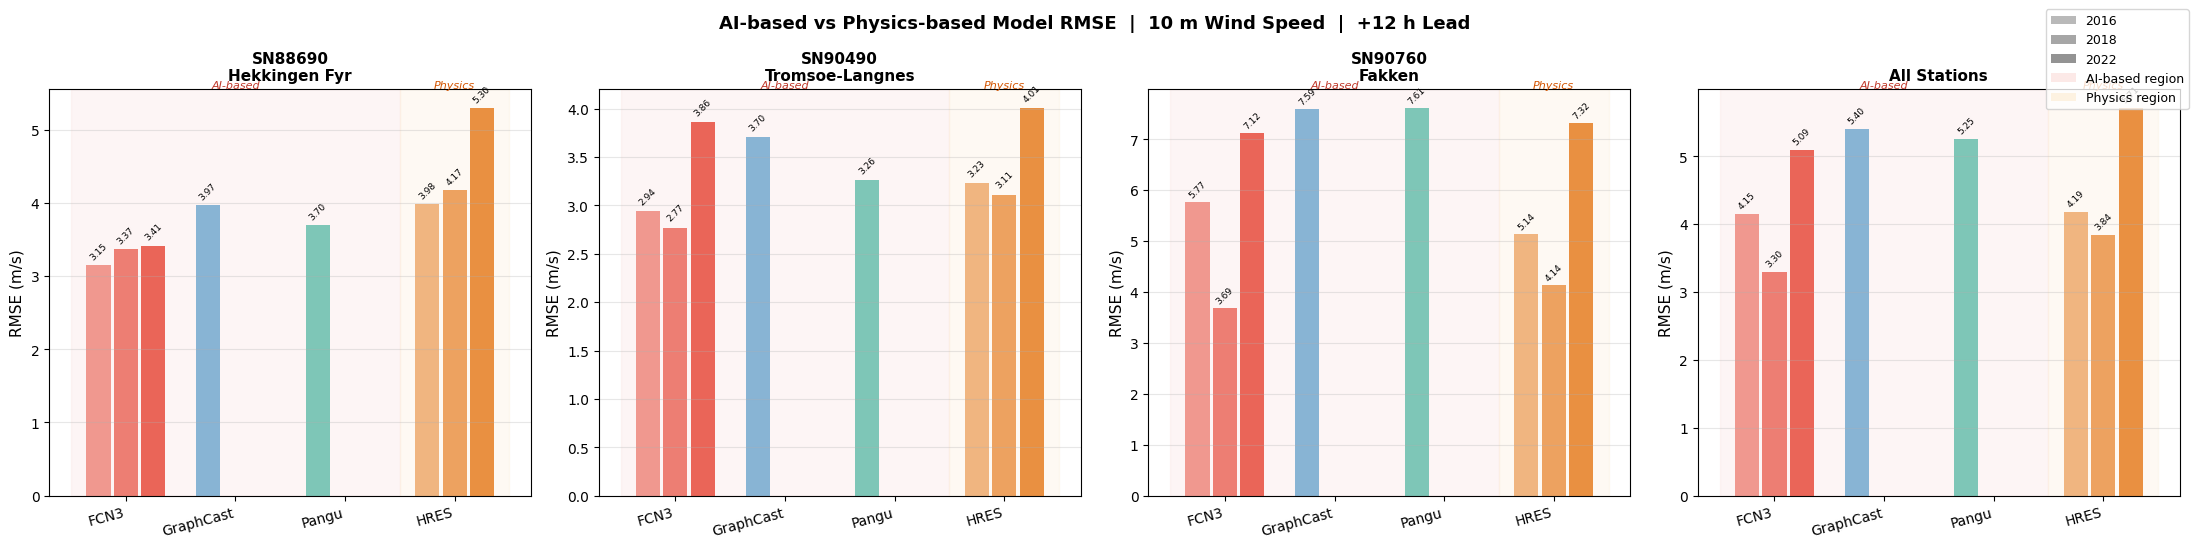

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/comparison_summary/ai_vs_physics_rmse.png


In [4]:
# ── Plot 1: AI vs Physics-based model performance ──────────────────────────
# Show RMSE for each model per year; shade AI vs Physics background.
# X-axis = models; groups = years; facets = stations

sids_all = list(STATIONS.keys()) + ['All Stations']
years    = [y for y in ['2016', '2018', '2022'] if y in dfs]

fig, axes = plt.subplots(1, len(sids_all), figsize=(5.5 * len(sids_all), 5.5), squeeze=False)
axes = axes[0]

YEAR_MARKERS = {'2016': 'o', '2018': 's', '2022': '^'}
YEAR_LINESTYLES = {'2016': '-', '2018': '--', '2022': ':'}

# Collect all models that appear across any year
all_models_ordered = ['FCN3', 'GraphCast', 'Pangu', 'HRES']

for col, sid in enumerate(sids_all):
    ax = axes[col]
    x_ticks, x_labels = [], []

    for i, model in enumerate(all_models_ordered):
        rmse_col = f'{model} RMSE'
        vals_by_year = {}
        for yr in years:
            if yr not in dfs: continue
            df = dfs[yr]
            if rmse_col not in df.columns: continue
            if sid not in df.index: continue
            vals_by_year[yr] = float(df.loc[sid, rmse_col])

        if not vals_by_year:
            continue

        # Bar for each year at position i, slightly offset
        n_yrs = len(vals_by_year)
        offsets = np.linspace(-0.25, 0.25, n_yrs)
        for j, (yr, rmse) in enumerate(sorted(vals_by_year.items())):
            clr = CLR.get(model, 'gray')
            alpha = 0.55 + 0.15 * j
            bar = ax.bar(i + offsets[j], rmse, 0.22, color=clr, alpha=alpha,
                         label=f'{model} {yr}' if col == 0 else '_')
            ax.text(i + offsets[j], rmse + 0.05, f'{rmse:.2f}',
                    ha='center', va='bottom', fontsize=6.5, rotation=45)

        x_ticks.append(i)
        x_labels.append(model)

    # Shade AI vs Physics regions
    n_ai = sum(1 for m in all_models_ordered if m in AI_MODELS and
               any(f'{m} RMSE' in dfs[y].columns for y in years if y in dfs))
    if n_ai > 0:
        ax.axvspan(-0.5, n_ai - 0.5, color='#FADBD8', alpha=0.25, zorder=0)
        ax.axvspan(n_ai - 0.5, len(all_models_ordered) - 0.5,
                   color='#FDEBD0', alpha=0.25, zorder=0)
        ax.text(n_ai / 2 - 0.5, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 5,
                'AI-based', ha='center', fontsize=8, color='#C0392B', style='italic')
        ax.text(n_ai + (len([m for m in all_models_ordered if m in PHYSICS_MODELS])) / 2 - 0.5,
                ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 5,
                'Physics', ha='center', fontsize=8, color='#D35400', style='italic')

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, fontsize=10, rotation=15, ha='right')
    ax.set_ylabel('RMSE (m/s)', fontsize=11)
    label = STATIONS.get(sid, sid)
    ax.set_title(f'{sid}' + (f'\n{label}' if sid != 'All Stations' else ''), fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

# Manual legend for years
from matplotlib.patches import Patch
handles = [Patch(facecolor='gray', alpha=0.55+0.15*j, label=yr)
           for j, yr in enumerate(sorted(years))]
handles += [Patch(facecolor='#FADBD8', alpha=0.6, label='AI-based region'),
            Patch(facecolor='#FDEBD0', alpha=0.6, label='Physics region')]
fig.legend(handles=handles, fontsize=9, loc='upper right', bbox_to_anchor=(1, 1))

fig.suptitle('AI-based vs Physics-based Model RMSE  |  10 m Wind Speed  |  +12 h Lead',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out = FIG_OUT / 'ai_vs_physics_rmse.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


## 3  RMSE Comparison Across Years (2016 / 2018 / 2022)

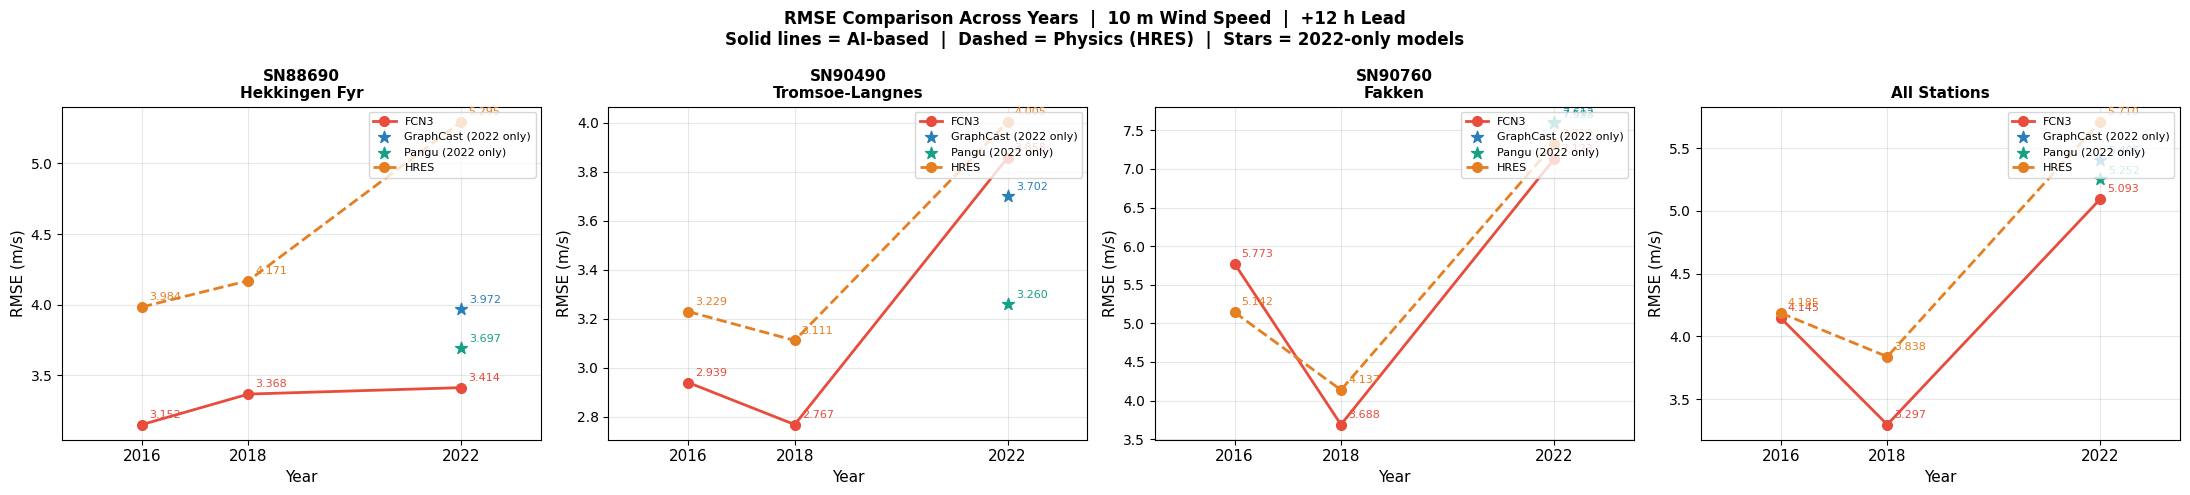

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/comparison_summary/rmse_across_years.png


In [7]:
# ── Plot 2: RMSE comparison across years ────────────────────────────────────
# Line chart: X = year, Y = RMSE, one line per model.
# GraphCast and Pangu are only available for 2022 (shown as isolated points).

years_num = {'2016': 2016, '2018': 2018, '2022': 2022}
sids_all  = list(STATIONS.keys()) + ['All Stations']

fig, axes = plt.subplots(1, len(sids_all), figsize=(5.5 * len(sids_all), 5), squeeze=False)
axes = axes[0]

for col, sid in enumerate(sids_all):
    ax = axes[col]

    for model in ['FCN3', 'GraphCast', 'Pangu', 'HRES']:
        rmse_col = f'{model} RMSE'
        pts = []
        for yr in sorted(years_num.keys()):
            if yr not in dfs: continue
            df = dfs[yr]
            if rmse_col not in df.columns: continue
            if sid not in df.index: continue
            pts.append((years_num[yr], float(df.loc[sid, rmse_col])))

        if not pts:
            continue

        xs = [p[0] for p in pts]
        ys = [p[1] for p in pts]
        clr = CLR.get(model, 'gray')

        if len(xs) == 1:
            # Only available for one year -> isolated point
            ax.scatter(xs, ys, color=clr, s=80, zorder=5,
                       marker='*', label=f'{model} (2022 only)')
            ax.annotate(f'{ys[0]:.3f}', (xs[0], ys[0]),
                        textcoords='offset points', xytext=(6, 4), fontsize=8, color=clr)
        else:
            ls = '-' if model in AI_MODELS else '--'
            ax.plot(xs, ys, color=clr, lw=2.0, linestyle=ls, marker='o', ms=7, label=model)
            for x, y in zip(xs, ys):
                ax.annotate(f'{y:.3f}', (x, y),
                            textcoords='offset points', xytext=(5, 5), fontsize=8, color=clr)

    ax.set_xticks(sorted(years_num.values()))
    ax.set_xticklabels(sorted(years_num.keys()), fontsize=11)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('RMSE (m/s)', fontsize=11)
    label = STATIONS.get(sid, sid)
    ax.set_title(f'{sid}' + (f'\n{label}' if sid != 'All Stations' else ''), fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)
    ax.set_xlim(2014.5, 2023.5)

fig.suptitle('RMSE Comparison Across Years  |  10 m Wind Speed  |  +12 h Lead\n'
             'Solid lines = AI-based  |  Dashed = Physics (HRES)  |  Stars = 2022-only models',
             fontsize=12, fontweight='bold')
plt.tight_layout()
out = FIG_OUT / 'rmse_across_years.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


## 4  Combined Metrics Table

In [6]:
# ── Print combined metrics table ────────────────────────────────────────────
rows = []
for yr, df in sorted(dfs.items()):
    rmse_cols = [c for c in df.columns if 'RMSE' in c]
    bias_cols = [c for c in df.columns if 'Bias' in c]
    for sid in list(STATIONS.keys()) + ['All Stations']:
        if sid not in df.index: continue
        row = {'Year': yr, 'Station': sid}
        for c in rmse_cols + bias_cols:
            row[c] = round(float(df.loc[sid, c]), 4)
        rows.append(row)

table = pd.DataFrame(rows)
print('Combined Metrics  |  +12 h Lead  |  All Years')
print('=' * 100)
print(table.to_string(index=False))


Combined Metrics  |  +12 h Lead  |  All Years
Year      Station  FCN3 RMSE  HRES RMSE  ΔRMSE HRES−FCN3  FCN3 Bias  HRES Bias  GraphCast RMSE  Pangu RMSE  ΔRMSE GraphCast−FCN3  ΔRMSE Pangu−FCN3  GraphCast Bias  Pangu Bias
2016      SN88690     3.1524     3.9845           0.8321    -1.8634    -3.1701             NaN         NaN                   NaN               NaN             NaN         NaN
2016      SN90490     2.9390     3.2290           0.2899    -1.9428    -2.3413             NaN         NaN                   NaN               NaN             NaN         NaN
2016      SN90760     5.7727     5.1424          -0.6303    -4.5827    -3.8854             NaN         NaN                   NaN               NaN             NaN         NaN
2016 All Stations     4.1450     4.1853           0.0403    -2.7831    -3.1267             NaN         NaN                   NaN               NaN             NaN         NaN
2018      SN88690     3.3682     4.1706           0.8025    -2.4677    -3.5592 